In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.size'] = 18 # Set the global font size

In [2]:
def outcome(pred_base, pred_weighted, label):
    """
    Compare baseline and weighted model predictions using a given evaluation mode.
    """
    # pred_base = pred_base.astype(int)
    # pred_weighted = pred_weighted.astype(int)
    # label = label.astype(int)

    base_correct = (pred_base == label)
    weighted_correct = (pred_weighted == label)


    if not base_correct and weighted_correct:
        return "Correction"
    elif base_correct and not weighted_correct:
        return "Mistake"
    elif base_correct and weighted_correct:
        return "both_correct"
    else:
        return "both_wrong"

In [3]:
def run_outcome_analysis(root_path, paths, missing, dataset, model_base='baseline', model_weighted='KL'):
    # Load CSVs
    runs = {}
    for run_name, path in paths.items():
        # df_train = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_train_results.csv')
        # df_dev   = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_dev_results.csv')
        if missing:
            df_test  = pd.read_csv(f'{root_path}/{path}/{dataset}_test_missingInd_results.csv')
        else:
            df_test  = pd.read_csv(f'{root_path}/{path}/{dataset}_test_results.csv')

        #df_train["split"] = "train"
        #df_dev["split"]   = "dev"
        df_test["split"]  = "test"
        df_test.drop(columns=['Probs', 'Proj'], inplace=True, errors='ignore')

        runs[run_name] = pd.concat([df_test], ignore_index=True)

    # Merge base and weighted runs
    merged = runs[model_base].merge(runs[model_weighted], on='ids', suffixes=(f'_{model_base}', f'_{model_weighted}'))

    # Keep a consistent GT and split column
    merged['Ground_Truth'] = merged[f'Ground_Truth_{model_base}']
    assert (merged[f'split_{model_base}'] == merged[f'split_{model_weighted}']).all()
    merged['split'] = merged[f'split_{model_base}']

    # Classification-style outcome labeling

    merged['outcome'] = merged.apply(
        lambda r: outcome(r[f'Predicted_{model_base}'], r[f'Predicted_{model_weighted}'], r['Ground_Truth']),
        axis=1
    )

    # Print summary for classification modes
    summary = {}
    counts = merged['outcome'].value_counts()
    summary = {
        'Correction': counts.get('Correction', 0),
        'Mistake': counts.get('Mistake', 0),
        'both_correct': counts.get('both_correct', 0),
        'both_wrong': counts.get('both_wrong', 0),
        'net_gain': counts.get('Correction', 0) - counts.get('Mistake', 0)
    }

    print(pd.DataFrame(summary.items(), columns=['Outcome', 'Count']).set_index('Outcome'))


    return merged


In [ ]:
def bar_plot(df, title):
    # ------------------------------------------------------------------
    # 1)  Split the dataframe by outcome
    # ------------------------------------------------------------------
    all_df       = df            # or whatever your merged DF is called
    fixed_df     = all_df[all_df["outcome"] == "Correction"]
    regressed_df = all_df[all_df["outcome"] == "Mistake"]

    # ------------------------------------------------------------------
    # 2)  Count how many examples fall into each LOS class (0-3)
    # ------------------------------------------------------------------
    def class_counts(df):
        """Return counts indexed by ground-truth class (0..3)."""
        return df["Ground_Truth"].value_counts().reindex([0,1,2,3], fill_value=0)

    all_cnt       = class_counts(all_df)
    fixed_cnt     = class_counts(fixed_df)
    regressed_cnt = class_counts(regressed_df)

    # optional: convert to % of total for easier visual comparison
    # fixed_cnt     = fixed_cnt / len(all_df) * 100
    # regressed_cnt = regressed_cnt / len(all_df) * 100
    # all_cnt       = all_cnt / len(all_df) * 100

    # ------------------------------------------------------------------
    # 3)  Bar-plot side-by-side
    # ------------------------------------------------------------------
    labels = [0,1,2,3]           # LOS classes
    x = np.arange(len(labels))   # bar positions
    width = 0.28                 # bar width

    fig, ax = plt.subplots(figsize=(8,4))

    ax.bar(x - width, all_cnt,       width, label="All",        color="lightgray")
    ax.bar(x,         fixed_cnt,     width, label="Correction",  color="mediumaquamarine")
    ax.bar(x + width, regressed_cnt, width, label="Mistake",  color="coral")

    for bars in ax.containers:
        ax.bar_label(bars)
    ax.set_ylim(0, 390)
    ax.set_xlabel("Ground-Truth LOS Class")
    ax.set_ylabel("Number of Patients")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"/data/wang/junh/results/Fuse_moe/{title}.pdf", bbox_inches='tight', pad_inches=0.1)
    plt.show()


In [5]:
root_path = "/data/wang/junh/results/Fuse_moe/all_los/multiclass"
paths = {
    "baseline":  "final/baseline",
    "MI":      "final/mi",
    "Global KL":  "final/global_kl",
    "KL":        "final/kl",
    "KL+MI":     "final/kl_mi"
}
missing = False

# No Missing

- Global MI vs baseline

In [6]:
dataset = "TS_CXR_Text_ECG"
mi_4mod = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="MI")

              Count
Outcome            
Correction       93
Mistake          80
both_correct    242
both_wrong      361
net_gain         13


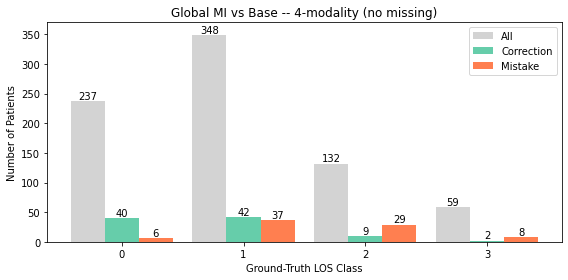

In [7]:
bar_plot(mi_4mod, "Global MI vs Base -- 4-modality (no missing)")

- KL vs baseline

In [6]:
dataset = "TS_CXR_Text_ECG"
kl_4mod = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL")

              Count
Outcome            
Correction      118
Mistake         101
both_correct    221
both_wrong      336
net_gain         17


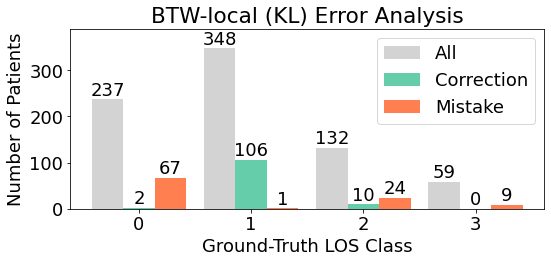

In [10]:
plt.rcParams['font.size'] = 18
bar_plot(kl_4mod, "BTW-local (KL) Error Analysis")

- KL+MI vs baseline

In [11]:
dataset = "TS_CXR_Text_ECG"
kl_mi_4mod = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL+MI")

              Count
Outcome            
Correction      113
Mistake          84
both_correct    238
both_wrong      341
net_gain         29


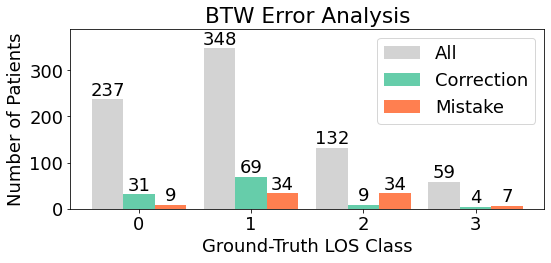

In [12]:
bar_plot(kl_mi_4mod, "BTW Error Analysis")

# Missing

In [79]:
missing = True

- Global MI vs baseline

In [80]:
dataset = "TS_CXR_Text_ECG"
mi_4mod_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="MI")

              Count
Outcome            
Correction      525
Mistake         556
both_correct   1696
both_wrong     2487
net_gain        -31


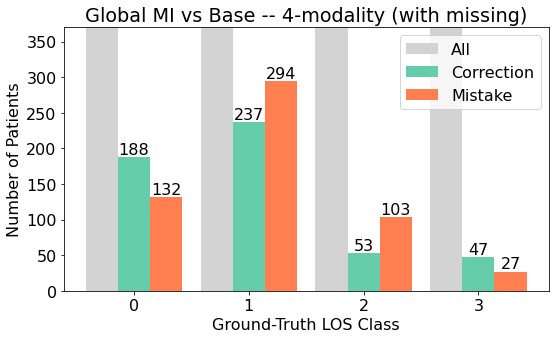

In [81]:
bar_plot(mi_4mod_miss, "Global MI vs Base -- 4-modality (with missing)")

In [82]:
dataset = "TS_CXR_Text"
mi_noECG_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="MI")

              Count
Outcome            
Correction      768
Mistake         872
both_correct   1541
both_wrong     2083
net_gain       -104


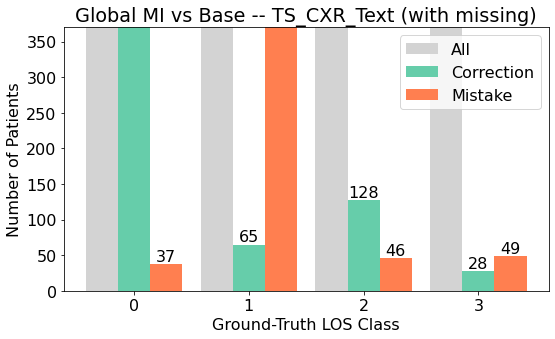

In [83]:
bar_plot(mi_noECG_miss, "Global MI vs Base -- TS_CXR_Text (with missing)")

In [84]:
dataset = "TS_CXR_ECG"
mi_noText_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="MI")

              Count
Outcome            
Correction      680
Mistake         666
both_correct   1786
both_wrong     2132
net_gain         14


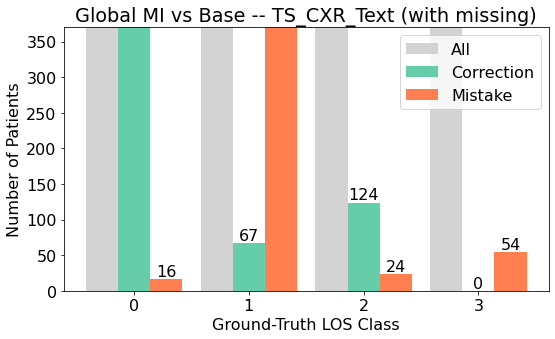

In [85]:
bar_plot(mi_noText_miss, "Global MI vs Base -- TS_CXR_Text (with missing)")

In [86]:
dataset = "TS_ECG_Text"
mi_noCXR_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="MI")

              Count
Outcome            
Correction      451
Mistake         433
both_correct   2002
both_wrong     2378
net_gain         18


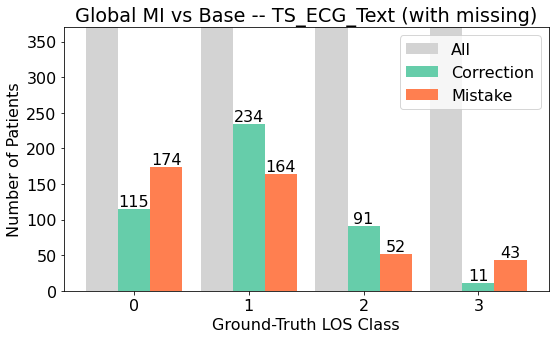

In [87]:
bar_plot(mi_noCXR_miss, "Global MI vs Base -- TS_ECG_Text (with missing)")

- KL vs baseline

In [88]:
dataset = "TS_CXR_Text_ECG"
kl_4mod_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL")

              Count
Outcome            
Correction      709
Mistake         585
both_correct   1667
both_wrong     2303
net_gain        124


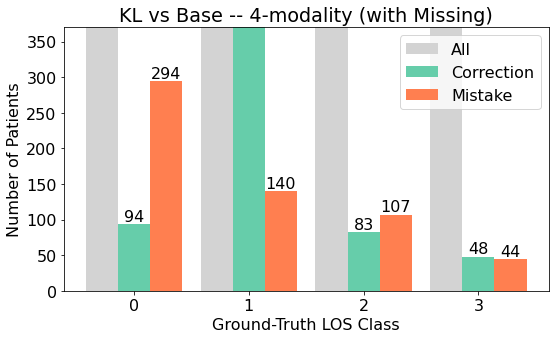

In [89]:
bar_plot(kl_4mod_miss, "KL vs Base -- 4-modality (with Missing)")

In [90]:
dataset = "TS_CXR_Text"
kl_noECG_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL")

              Count
Outcome            
Correction      713
Mistake         733
both_correct   1680
both_wrong     2138
net_gain        -20


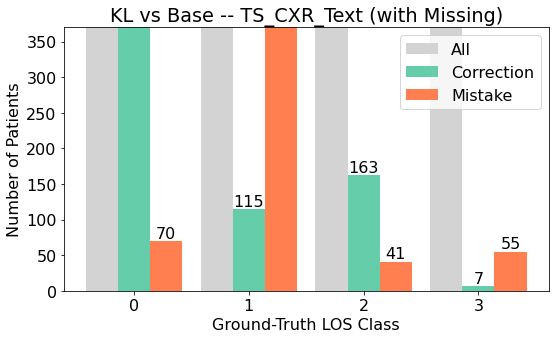

In [91]:
bar_plot(kl_noECG_miss, "KL vs Base -- TS_CXR_Text (with Missing)")

In [92]:
dataset = "TS_ECG_Text"
kl_noCXR_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL")

              Count
Outcome            
Correction     1045
Mistake        1297
both_correct   1138
both_wrong     1784
net_gain       -252


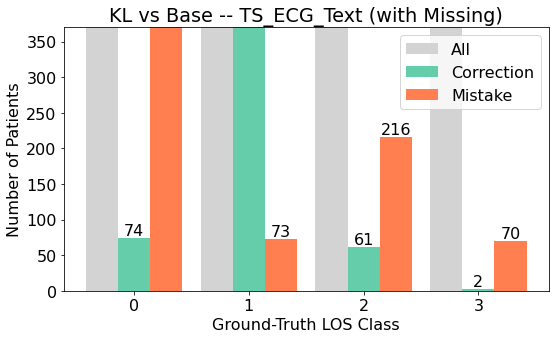

In [93]:
bar_plot(kl_noCXR_miss, "KL vs Base -- TS_ECG_Text (with Missing)")

In [94]:
dataset = "TS_CXR_ECG"
kl_noText_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL")

              Count
Outcome            
Correction      672
Mistake         926
both_correct   1526
both_wrong     2140
net_gain       -254


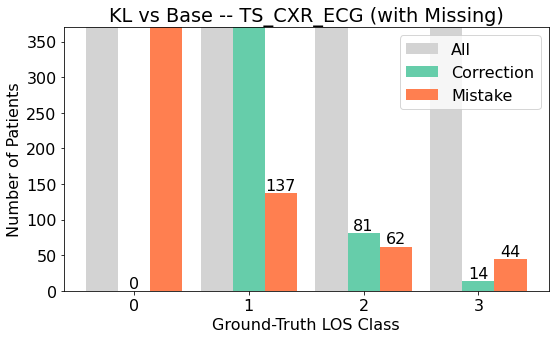

In [95]:
bar_plot(kl_noText_miss, "KL vs Base -- TS_CXR_ECG (with Missing)")

- KL+MI vs baseline

In [96]:
dataset = "TS_CXR_Text_ECG"
kl_mi_4mod_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL+MI")

              Count
Outcome            
Correction      773
Mistake         750
both_correct   1502
both_wrong     2239
net_gain         23


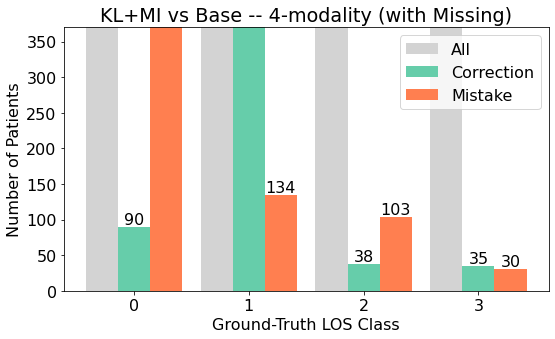

In [97]:
bar_plot(kl_mi_4mod_miss, "KL+MI vs Base -- 4-modality (with Missing)")

In [98]:
dataset = "TS_CXR_Text"
kl_mi_noECG_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL+MI")

              Count
Outcome            
Correction      694
Mistake         649
both_correct   1764
both_wrong     2157
net_gain         45


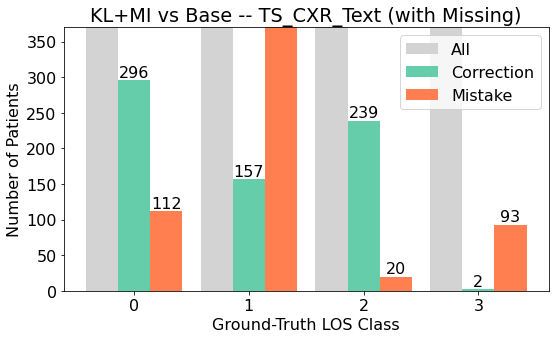

In [99]:
bar_plot(kl_mi_noECG_miss, "KL+MI vs Base -- TS_CXR_Text (with Missing)")

In [100]:
dataset = "TS_ECG_Text"
kl_mi_noCXR_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL+MI")

              Count
Outcome            
Correction      835
Mistake         987
both_correct   1448
both_wrong     1994
net_gain       -152


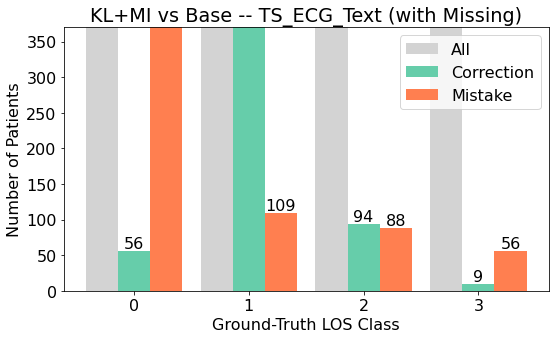

In [101]:
bar_plot(kl_mi_noCXR_miss, "KL+MI vs Base -- TS_ECG_Text (with Missing)")

In [102]:
dataset = "TS_CXR_ECG"
kl_mi_noText_miss = run_outcome_analysis(root_path, paths, missing, dataset, model_base="baseline", model_weighted="KL+MI")

              Count
Outcome            
Correction      552
Mistake         643
both_correct   1809
both_wrong     2260
net_gain        -91


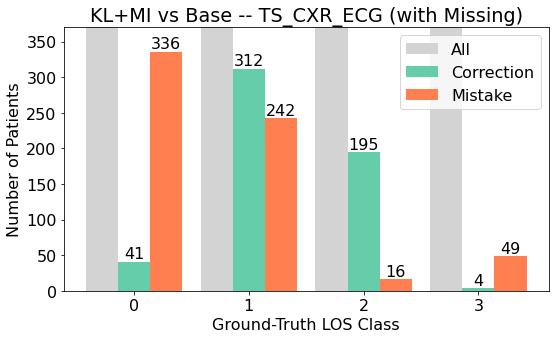

In [103]:
bar_plot(kl_mi_noText_miss, "KL+MI vs Base -- TS_CXR_ECG (with Missing)")